# **Laboratorio 1**
Angel David Gonzales - 202116628 - seccion 1

**Caso AlpesPlanck.** Predecir `temp_max_manana`, la temperatura maxima del dia siguiente en la
estacion de Jena, e identificar que variables aportan mas a esa prediccion.

Algo importante que note al abrir los datos: no hay ninguna columna con la temperatura del dia actual.
Solo hay presion, humedad, viento y la fecha.

Contenido:
1. Exploracion de datos
2. Preparacion de datos
3. Construccion del modelo de regresion lineal
4. Evaluacion cuantitativa
5. Evaluacion cualitativa

## 1. Importación de las librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_rainbow, het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import shapiro, ttest_1samp
import scipy.stats as stats

In [2]:
from importlib.metadata import version
print(f"Versión de Pandas: {version('pandas')}")
print(f"Versión de Matplotlib: {version('matplotlib')}")
print(f"Versión de Seaborn: {version('seaborn')}")
print(f"Versión de Scikit learn: {version('scikit-learn')}")
print(f"Versión de Statsmodels: {version('statsmodels')}")

Versión de Pandas: 2.3.3
Versión de Matplotlib: 3.9.4
Versión de Seaborn: 0.13.2
Versión de Scikit learn: 1.6.1
Versión de Statsmodels: 0.14.6


## 1) Exploracion de datos

Importar pandas, cargar datos y copia

In [3]:
datos_clima = pd.read_csv("L1/data/Datos Lab 1.csv")
data = datos_clima.copy()

Primeros 5 datos

In [4]:
data.head()

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,2009-01-01,999.1456,996.50,1000.87,1.3993,0.910860,0.875000,94.8,1.7650,0.7786,...,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,January,S,-2.12
1,2009-01-02,999.6006,997.93,1002.65,1.5039,0.920868,86.600000,96.3,2.7588,1.4195,...,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,JULY,NE,-0.82
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.2509,...,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,January,SO,-0.63
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.7204,...,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,JANUARY,SO,-1.44
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.260400,74.600000,93.2,5.3922,3.8003,...,2.6275,0.2874,6.2418,NaN,2009.0,5.0,East,January,N,-10.88


Tamaño de datos (filas, columnas)

In [5]:
data.shape

(2576, 27)

Tipos de variables

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2576 entries, 0 to 2575
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fecha              2504 non-null   object 
 1   presion_media      2501 non-null   float64
 2   presion_min        2502 non-null   float64
 3   presion_max        2512 non-null   float64
 4   presion_desv       2496 non-null   float64
 5   humedad_media      2502 non-null   float64
 6   humedad_min        2496 non-null   float64
 7   humedad_max        2490 non-null   float64
 8   humedad_desv       2515 non-null   float64
 9   viento_media       2490 non-null   float64
 10  viento_min         2485 non-null   float64
 11  viento_max         2495 non-null   float64
 12  viento_desv        2504 non-null   float64
 13  rafaga_media       2498 non-null   float64
 14  rafaga_min         2504 non-null   float64
 15  rafaga_max         2503 non-null   float64
 16  rafaga_desv        2497 

Diccionario de datos

In [7]:
dict = pd.read_excel("L1/data/Diccionario de datos.xlsx")
pd.set_option('display.max_colwidth', None)
dict

,variable,tipo,descripcion
0,fecha,texto,"Fecha de la observación, en formato día.mes.año."
1,presion_media,numérico,Presión atmosférica media del día (mbar).
2,presion_min,numérico,Presión atmosférica mínima del día (mbar).
3,presion_max,numérico,Presión atmosférica máxima del día (mbar).
4,presion_desv,numérico,Desviación típica de la presión durante el día (mbar).
5,humedad_media,numérico,Humedad relativa media del día (%).
6,humedad_min,numérico,Humedad relativa mínima del día (%).
7,humedad_max,numérico,Humedad relativa máxima del día (%).
8,humedad_desv,numérico,Desviación típica de la humedad relativa (%).
9,viento_media,numérico,Velocidad media del viento durante el día (m/s).


Del diccionario saco las reglas que uso despues para revisar validez:

* la humedad esta en porcentaje, o sea entre 0 y 100
* el viento y las rafagas estan en m/s
* `registros_del_dia` cuenta mediciones de 10 minutos y un dia completo son 144
* `temp_max_manana` es la variable objetivo

Clasificación de tipos de variables

In [8]:
cuantitativas_continuas = ['presion_media', 'presion_min', 'presion_max', 'presion_desv',
                           'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv',
                           'viento_media', 'viento_min', 'viento_max', 'viento_desv',
                           'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv',
                           'viento_norte', 'viento_este', 'temp_max_manana']

cuantitativas_discretas = ['registros_del_dia', 'anio', 'dia_del_anio', 'direccion_viento']
cualitativas_ordinales  = ['mes', 'estacion_anio']
cualitativas_nominales  = ['fecha', 'sector_viento']

print("Cuantitativas continuas :", len(cuantitativas_continuas))
print("Cuantitativas discretas :", len(cuantitativas_discretas))
print("Cualitativas ordinales  :", len(cualitativas_ordinales))
print("Cualitativas nominales  :", len(cualitativas_nominales))

Cuantitativas continuas : 19
Cuantitativas discretas : 4
Cualitativas ordinales  : 2
Cualitativas nominales  : 2


`dia_del_anio` y `direccion_viento` son numericas pero ciclicas: el dia 366 esta a un dia del dia 1,
y 359 grados esta a 1 grado de 0. Si las dejo asi el modelo va a pensar que el 31 de diciembre y el
1 de enero son los dias mas distintos del año. Esto lo corrijo en la preparacion.

### Completitud

In [9]:
((data.isnull().sum()/data.shape[0])).sort_values(ascending=False)

temp_max_manana      0.036879
viento_min           0.035326
estacion_anio        0.034161
mes                  0.034161
anio                 0.033385
humedad_max          0.033385
viento_media         0.033385
viento_max           0.031444
humedad_min          0.031056
viento_norte         0.031056
presion_desv         0.031056
rafaga_desv          0.030668
direccion_viento     0.030668
rafaga_media         0.030280
registros_del_dia    0.029891
presion_media        0.029115
presion_min          0.028727
humedad_media        0.028727
rafaga_max           0.028339
rafaga_min           0.027950
viento_desv          0.027950
fecha                0.027950
sector_viento        0.027562
dia_del_anio         0.026398
presion_max          0.024845
viento_este          0.024845
humedad_desv         0.023680
dtype: float64

In [10]:
print("Filas con al menos un nulo:", data.isnull().any(axis=1).sum())
print("Nulos en la variable objetivo:", data['temp_max_manana'].isnull().sum())

Filas con al menos un nulo: 1454
Nulos en la variable objetivo: 95


Las 27 columnas tienen nulos, entre 2.4% y 3.7% cada una. Individualmente es poco, pero como no estan
en las mismas filas se propagan: casi el 57% de las filas tiene al menos un nulo. Eso descarta borrar
filas incompletas, porque perderia mas de la mitad de los datos.

### Unicidad

In [11]:
print("Número de registros duplicados:", int(data.duplicated(keep=False).sum()))
print("Fechas duplicadas:", int(data.duplicated(subset=['fecha']).sum()))

Número de registros duplicados: 8
Fechas duplicadas: 89


In [12]:
# detalle de las fechas repetidas
dup_counts = (data['fecha'].value_counts()
                           .loc[lambda s: s > 1]
                           .sort_values(ascending=False))
print(f"Fechas que aparecen mas de una vez: {len(dup_counts)}")
data[data['fecha'] == dup_counts.index[0]]

Fechas que aparecen mas de una vez: 18


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
63,2009-03-05,959.8607,958.67,962.54,0.8964,94.2944,86.0,97.8,2.8296,1.2908,...,1.1131,0.1826,9.3166,144.0,2009.0,64.0,primavera,July,N,5.370000
2574,2009-03-05,959.8607,958.67,962.54,0.8964,NaN,86.0,97.8,2.8296,1.2908,...,1.1131,0.1826,9.3166,144.0,2009.0,64.0,primavera,July,N,5.956009


Hay 4 filas identicas y 89 fechas repetidas con valores distintos entre si. Una fecha representa un
dia de observacion, asi que dos filas con la misma fecha son el mismo registro aunque los numeros
cambien.

### Validez de las variables numericas

In [13]:
data.describe()

,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,...,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,temp_max_manana
count,2501.000000,2502.000000,2512.000000,2496.000000,2502.000000,2496.000000,2490.000000,2515.000000,2490.000000,2485.000000,...,2504.000000,2503.000000,2497.000000,2496.000000,2512.000000,2497.000000,2499.000000,2490.000000,2508.000000,2481.000000
mean,1010.494271,986.684409,991.704244,1.752041,52.413586,45.094067,90.236582,10.606821,3.814103,1.417799,...,-2.639322,6.946058,-5.763253,-1.128463,-0.410159,172.104573,144.090836,2011.995582,182.690989,13.863309
std,435.334494,8.927138,7.726906,1.215931,35.975384,30.196163,10.647237,5.481338,3.307402,3.960650,...,199.861693,3.237379,75.258134,25.065084,1.147218,86.102348,4.107365,1.999694,105.529469,9.296199
min,948.996000,913.600000,951.940000,0.226900,0.004663,0.237700,27.020000,0.000000,0.000000,0.000000,...,-9999.000000,0.000000,-232.260000,-1250.463300,-3.718500,0.000000,90.000000,2009.000000,1.000000,-15.230000
25%,984.287800,981.371333,987.070000,0.899050,0.869060,1.011790,88.025000,6.082100,1.655350,0.230000,...,0.440000,4.803198,1.002100,-1.640625,-1.236475,91.303500,144.000000,2010.000000,91.000000,7.310000
50%,989.452800,987.070000,991.935000,1.444550,68.558100,49.670000,93.300000,10.199800,2.463400,0.440000,...,0.660000,6.690000,1.461100,-0.564300,-0.356000,199.568500,144.000000,2012.000000,182.500000,14.310000
75%,994.469000,992.567500,996.782500,2.254800,80.562600,67.665000,96.600000,14.722200,4.880505,0.960000,...,1.120000,8.850000,2.008800,0.241525,0.316275,227.101700,144.000000,2014.000000,274.250000,20.460000
max,9939.918000,1012.320198,1013.940000,12.397500,100.000000,103.311405,100.000000,26.341600,24.753600,45.184956,...,19.895916,23.500000,3471.027800,4.809900,4.713900,359.796700,287.000000,2015.000000,366.000000,63.050000


Aca salen los problemas mas evidentes mirando los minimos y maximos:

* `presion_media` llega a 9939.9 mbar cuando lo normal esta entre 950 y 1050
* `humedad_media` tiene minimo 0.0047 pero mediana 68.6
* `humedad_min` llega a 103.3 %, y la humedad relativa no pasa de 100
* `rafaga_min` tiene minimo -9999, tipico valor centinela de dato faltante
* `rafaga_desv` tiene minimo -232, y una desviacion no puede ser negativa
* `viento_desv` llega a 3319 m/s
* `registros_del_dia` llega a 287 cuando el maximo son 144
* `temp_max_manana` llega a 63 °C, imposible en Alemania

In [14]:
print("humedad > 100 %:       ", int((data[['humedad_media','humedad_min','humedad_max']] > 100).sum().sum()))
print("presion fuera de rango:", int(((data['presion_media'] < 900) | (data['presion_media'] > 1050)).sum()))
print("rafaga_min == -9999:   ", int((data['rafaga_min'] == -9999).sum()))
print("rafaga_desv negativa:  ", int((data['rafaga_desv'] < 0).sum()))
print("viento_desv > 5 m/s:   ", int((data['viento_desv'] > 5).sum()))
print("registros_del_dia >144:", int((data['registros_del_dia'] > 144).sum()))

humedad > 100 %:        23
presion fuera de rango: 6
rafaga_min == -9999:    1
rafaga_desv negativa:   258
viento_desv > 5 m/s:    261
registros_del_dia >144: 4


In [15]:
# el minimo del dia no puede ser mayor que el maximo del mismo dia
for bajo, alto in [('presion_min','presion_max'), ('humedad_min','humedad_max'),
                   ('viento_min','viento_max'), ('rafaga_min','rafaga_max')]:
    print(f"{bajo} > {alto}: {int((data[bajo] > data[alto]).sum())} filas")

presion_min > presion_max: 121 filas
humedad_min > humedad_max: 98 filas
viento_min > viento_max: 120 filas
rafaga_min > rafaga_max: 122 filas


### Consistencia de las variables categoricas

In [16]:
data.describe(include='object')

,fecha,estacion_anio,mes,sector_viento
count,2504,2488,2488,2505
unique,2486,28,61,33
top,2009-03-05,primavera,May,SO
freq,2,517,127,695


In [17]:
print("mes:", data['mes'].nunique(), "valores distintos")
print(data['mes'].unique())

mes: 61 valores distintos
['January' 'JULY' 'JANUARY' 'May' 'Enero' nan 'JUNE' 'Sep' 'April'
 'SEPTEMBER' 'noviembre' 'octubre' 'Sept' 'november' 'april' 'julio'
 'February' 'APRIL' 'Aug' 'febrero' 'septiembre' 'Mar' 'Nov' 'MARCH'
 'february' 'November' 'may' 'july' 'august' 'september' 'July' 'March'
 'October' 'junio' 'october' 'march' 'marzo' 'September' 'Oct' 'DECEMBER'
 'Jan' 'enero' 'NOVEMBER' 'december' 'Jul' 'OCTOBER' 'Jun' 'diciembre'
 'AUGUST' 'June' 'january' 'june' 'Feb' 'August' 'December' 'agosto' 'Apr'
 'mayo' 'abril' 'FEBRUARY' 'MAY' 'Dec']


In [18]:
print("estacion_anio:", data['estacion_anio'].nunique(), "valores distintos")
print(data['estacion_anio'].unique())

estacion_anio: 28 valores distintos
['invierno' 'East' nan 'Estacion_Desconocida' 'verano' 'Inverano'
 'invierno ' 'INVIERNO' 'VERANO_INVIERNO' 'Verano' 'primavera' 'Primavera'
 'primaveraa' 'PRIMAVERA' 'berano' 'VERANO' 'verno' 'otono' 'otoño '
 'fall' 'autumn' 'OTONO' 'winter' 'invernio' 'primav' 'spring' 'Otoño'
 'Invierno' 'summer']


In [19]:
data['estacion_anio'].value_counts()

estacion_anio
primavera               517
invierno                511
otono                   500
verano                  487
Inverano                 71
Estacion_Desconocida     63
VERANO_INVIERNO          60
East                     48
VERANO                   19
autumn                   18
berano                   17
primaveraa               17
fall                     15
winter                   15
verno                    14
Otoño                    12
invernio                 11
otoño                    11
PRIMAVERA                10
Primavera                10
Verano                    9
INVIERNO                  9
invierno                  9
Invierno                  9
OTONO                     8
primav                    6
spring                    6
summer                    6
Name: count, dtype: int64

In [20]:
print("sector_viento:", data['sector_viento'].nunique(), "valores distintos")
print(data['sector_viento'].unique())

sector_viento: 33 valores distintos
['S' 'NE' 'SO' 'N' 'South' 'Sureste' nan 'Suroeste' 'Noreste' 'Sur' 'O'
 'North' 'so' 'Oeste' 'o' 'E' 'NORTHEAST' 'NO' 'NORTH' 'SE' 'Noroeste'
 'SOUTHWEST' 'West' 's' 'WEST' 'SOUTH' 'ne' 'East' 'NORTHWEST' 'no' 'EAST'
 'SOUTHEAST' 'Este' 'Norte']


Las tres categoricas mezclan idiomas (`julio` / `July` / `Jul`, `otono` / `fall` / `autumn`),
mayusculas y minusculas, espacios de mas (`'invierno '`), errores de escritura (`berano`, `verno`,
`invernio`, `primaveraa`), valores que no son del dominio (`East` es una direccion, no una estacion)
y un valor que en realidad es un nulo (`Estacion_Desconocida`).

Quedan 63 formas de escribir 12 meses, 29 para 4 estaciones y 34 para 8 sectores. Con One-Hot
Encoding asi como esta me saldrian decenas de columnas basura.

### Consistencia de las unidades

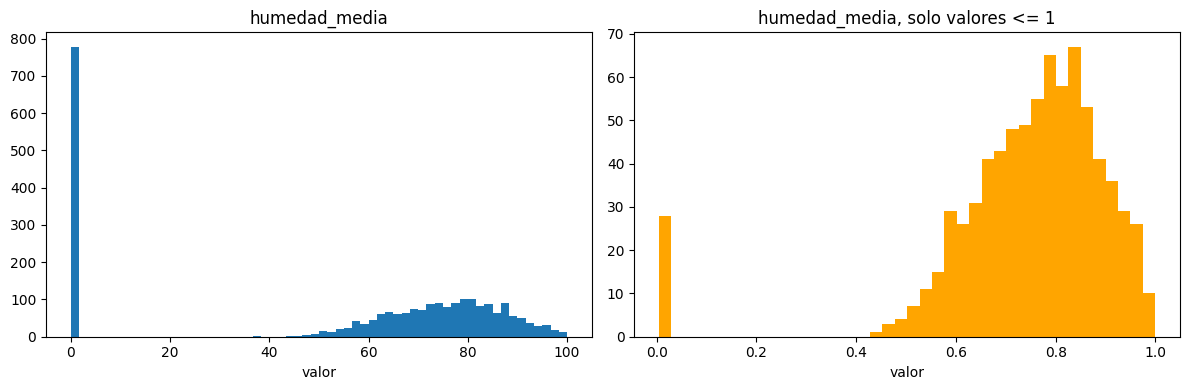

humedad_media -> valores <= 1: 776
humedad_min -> valores <= 1: 621
humedad_max -> valores <= 1: 0
humedad_desv -> valores <= 1: 20


In [21]:
plt.figure(figsize=(12,4))

plt.subplot(1, 2, 1)
plt.hist(data['humedad_media'].dropna(), bins=60)
plt.title('humedad_media')
plt.xlabel('valor')

plt.subplot(1, 2, 2)
plt.hist(data.loc[data['humedad_media'] <= 1, 'humedad_media'], bins=40, color='orange')
plt.title('humedad_media, solo valores <= 1')
plt.xlabel('valor')

plt.tight_layout()
plt.show()

for c in ['humedad_media','humedad_min','humedad_max','humedad_desv']:
    print(c, "-> valores <= 1:", int((data[c] <= 1).sum()))

Los valores entre 0 y 1 se reparten igual que los que estan entre 0 y 100: son los mismos datos pero
escritos como fraccion en vez de porcentaje. Pasa en `humedad_media` (776) y `humedad_min` (621),
pero no en `humedad_max`.

`humedad_desv` tambien tiene 20 valores menores a 1, pero ahi si es normal porque es una desviacion y
un dia con humedad estable puede tenerla baja. A esa columna no le hago nada.

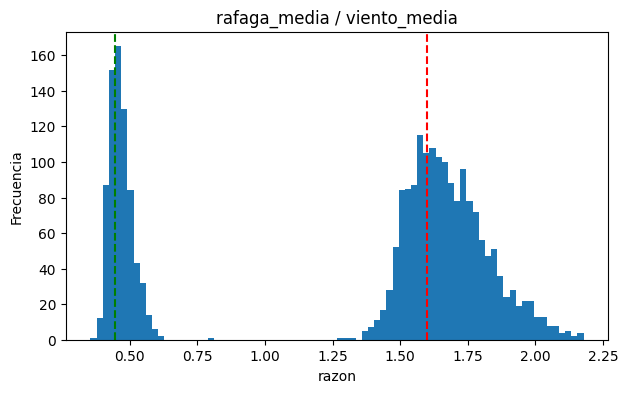

percentiles: [0.43 0.51 1.58 1.72 1.93]


In [22]:
# la rafaga siempre deberia ser mas fuerte que el viento medio
razon = (data['rafaga_media'] / data['viento_media']).replace([np.inf, -np.inf], np.nan).dropna()

plt.figure(figsize=(7,4))
plt.hist(razon, bins=80)
plt.axvline(1.6, color='red', linestyle='--')
plt.axvline(1.6/3.6, color='green', linestyle='--')
plt.title('rafaga_media / viento_media')
plt.xlabel('razon')
plt.ylabel('Frecuencia')
plt.show()

print("percentiles:", np.round(np.percentile(razon, [5, 25, 50, 75, 95]), 2))

El histograma tiene dos picos: uno en 1.6 (lo esperado) y otro en 0.44. Y 1.6 / 0.44 = 3.6, que es
justo el factor para pasar de km/h a m/s. Entonces hay celdas de viento y rafaga en km/h en vez de
m/s. Es celda por celda, no fila por fila: en una misma fila `viento_media` puede estar en km/h y
`viento_max` en m/s.

### La variable objetivo

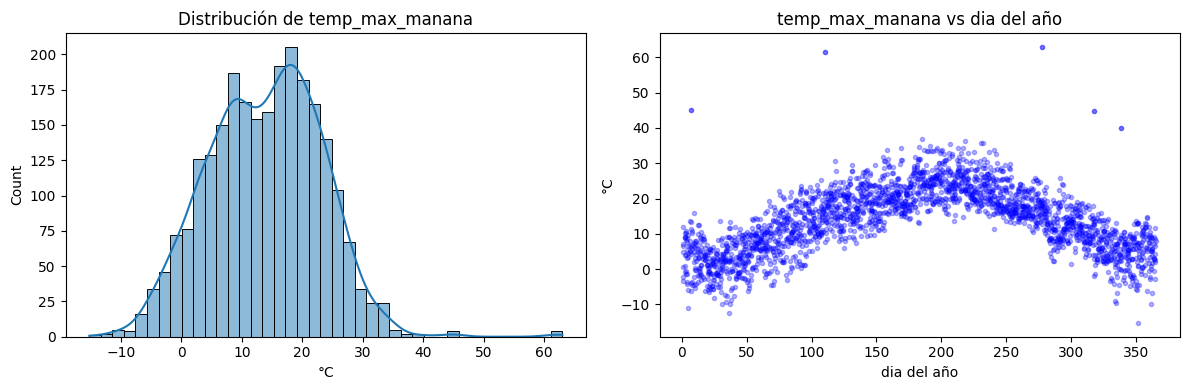

In [23]:
plt.figure(figsize=(12,4))

plt.subplot(1, 2, 1)
sns.histplot(x=data['temp_max_manana'], kde=True)
plt.title('Distribución de temp_max_manana')
plt.xlabel('°C')

plt.subplot(1, 2, 2)
plt.plot(data['dia_del_anio'], data['temp_max_manana'], '.', color='blue', alpha=0.3)
plt.title('temp_max_manana vs dia del año')
plt.xlabel('dia del año')
plt.ylabel('°C')

plt.tight_layout()
plt.show()

El grafico de la derecha es el hallazgo mas importante de la exploracion: la temperatura sigue una
onda muy clara segun el dia del año. Como no tengo la temperatura de hoy, esa onda es la señal mas
fuerte que tengo.

Tambien se ven puntos sueltos muy por encima de la nube, como 45 °C en enero. Los reviso con un
boxplot por estacion, porque 30 °C es normal en verano pero absurdo en invierno.

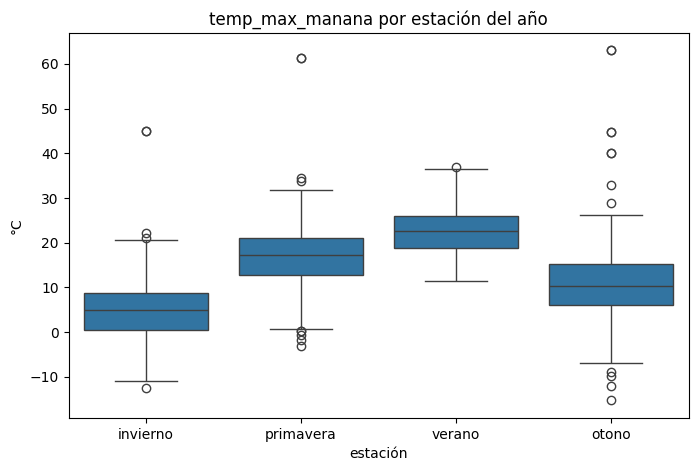

,count,mean,std,min,25%,50%,75%,max
estacion_calc,,,,,,,,
invierno,593.0,4.8,6.2,-12.5,0.6,4.9,8.7,45.0
otono,652.0,10.7,7.8,-15.2,6.0,10.4,15.2,63.0
primavera,618.0,17.0,6.5,-3.1,12.8,17.3,21.0,61.4
verano,618.0,22.7,5.0,11.5,18.8,22.5,26.0,37.0


In [24]:
def estacion_del_anio(dia):
    if dia < 80 or dia >= 355:
        return 'invierno'
    elif dia < 172:
        return 'primavera'
    elif dia < 266:
        return 'verano'
    else:
        return 'otono'

data['estacion_calc'] = data['dia_del_anio'].apply(estacion_del_anio)

plt.figure(figsize=(8,5))
sns.boxplot(x=data['estacion_calc'], y=data['temp_max_manana'],
            order=['invierno','primavera','verano','otono'])
plt.title('temp_max_manana por estación del año')
plt.xlabel('estación')
plt.ylabel('°C')
plt.show()

data.groupby('estacion_calc')['temp_max_manana'].describe().round(1)

Las cuatro cajas estan donde uno esperaria, pero hay bigotes que se salen completamente. Comparando
el maximo de cada estacion con su percentil 75 se ve que son unos pocos puntos muy separados del
resto, no una cola continua.

### Comparacion con el archivo de test

Antes de decidir como limpiar compare con el archivo de test, que es el que no tiene etiqueta, para
ver como deberian verse los datos buenos.

In [25]:
test = pd.read_csv("L1/data/Datos Test Lab 1.csv")

comparacion = pd.DataFrame({
    'entrenamiento': [data.isnull().sum().sum(), data['estacion_anio'].nunique(),
                      data['mes'].nunique(), data['sector_viento'].nunique(),
                      round(data['humedad_media'].min(), 3), round(data['presion_media'].max(), 1),
                      f"{data['anio'].min():.0f}-{data['anio'].max():.0f}"],
    'test':          [test.isnull().sum().sum(), test['estacion_anio'].nunique(),
                      test['mes'].nunique(), test['sector_viento'].nunique(),
                      round(test['humedad_media'].min(), 3), round(test['presion_media'].max(), 1),
                      f"{test['anio'].min():.0f}-{test['anio'].max():.0f}"],
}, index=['nulos', 'categorias estacion', 'categorias mes', 'categorias sector',
          'min humedad_media', 'max presion_media', 'años'])
comparacion

,entrenamiento,test
nulos,2094,0
categorias estacion,28,4
categorias mes,61,12
categorias sector,33,8
min humedad_media,0.005,44.422
max presion_media,9939.9,1014.0
años,2009-2015,2016-2016


El archivo de test esta limpio: cero nulos, 4 estaciones, 12 meses, 8 sectores y todo dentro de rango.
Los errores estan solo en el archivo de entrenamiento. Osea que limpiar no es opcional: si entreno
con humedades en escala 0-1 y vientos en km/h, el modelo aprende relaciones que no se cumplen en los
datos sobre los que va a predecir.

Ademas el test es todo del 2016 y el entrenamiento va del 2009 al 2015, entonces `anio` no me sirve
como predictora porque el modelo tendria que extrapolar a un año que nunca vio.

## Observación y Decisiones

**A1. Completitud.** Todas las columnas tienen entre 2.4% y 3.7% de nulos y el 57% de las filas tiene
al menos uno. Como estan muy por debajo del 5% la decision es imputar, no eliminar variables. Uso
`SimpleImputer` con `strategy='median'` para las numericas, mejor que la media porque hay outliers
que corren el promedio, y `most_frequent` para las categoricas. Para `temp_max_manana` imputar no es
valido porque no puedo inventarme la etiqueta, ahi va `dropna`.

**A2. Unicidad.** 4 filas identicas y 89 fechas repetidas. Como una fecha es un dia de observacion,
hago `drop_duplicates()` y despues `drop_duplicates(subset='fecha', keep='first')` para no perder
esos 89 dias completos.

**A3. Consistencia.** Dos cosas distintas. Las unidades mezcladas las corrijo: los valores de humedad
menores o iguales a 1 los multiplico por 100, y los de viento mayores a 25 m/s (90 km/h) los divido
entre 3.6. El formato de texto de `mes`, `estacion_anio` y `sector_viento` no lo arreglo con un
diccionario de mapeo, porque tocaria escribir 63 entradas solo para `mes`. En vez de eso reconstruyo
`estacion_anio` desde `dia_del_anio`, que si esta limpio, y descarto `mes` (redundante con
`dia_del_anio`) y `sector_viento` (la direccion ya esta en `direccion_viento`).

**A4. Validez.** Todo lo que viola un limite fisico o del diccionario lo paso a nulo para que despues
lo impute el pipeline: el centinela -9999, las desviaciones negativas o mayores a 5, la presion fuera
de 900-1050, la humedad fuera de 0-100, `registros_del_dia` mayor a 144 y las filas donde el minimo
del dia supera al maximo (ahi pongo los dos en nulo porque no se cual esta mal). Las temperaturas
imposibles para su estacion si las elimino, porque es la variable objetivo.

**A5. Diseño.** Saco `anio` para que el modelo no tenga que extrapolar a 2016, y transformo
`dia_del_anio` y `direccion_viento` con seno y coseno para que un modelo lineal pueda usar el ciclo.

## 2) Preparación De los Datos

Separo la preparacion en dos partes. Lo que cambia el numero de filas (duplicados, nulos en la
etiqueta, temperaturas imposibles) va antes de la particion. Lo que necesita estadisticas del
conjunto (imputar, escalar, One-Hot) va dentro del pipeline, para que se calcule solo con train y no
haya data leakage.

In [26]:
data = datos_clima.copy()
print("Shape inicial:", data.shape)

Shape inicial: (2576, 27)


In [27]:
# unicidad
data = data.drop_duplicates()
data = data.drop_duplicates(subset='fecha', keep='first')
print("Shape tras corregir unicidad:", data.shape)

Shape tras corregir unicidad: (2487, 27)


In [28]:
# la variable objetivo no se imputa
data = data.dropna(subset=['temp_max_manana', 'dia_del_anio'])
print("Shape tras eliminar nulos en el objetivo:", data.shape)

Shape tras eliminar nulos en el objetivo: (2331, 27)


In [29]:
# temperaturas imposibles para su estación
limites = {'invierno': (-25, 30), 'primavera': (-15, 40),
           'verano':   (0, 42),   'otono':     (-20, 35)}

data['estacion_calc'] = data['dia_del_anio'].apply(estacion_del_anio)
data['lim_bajo'] = data['estacion_calc'].apply(lambda e: limites[e][0])
data['lim_alto'] = data['estacion_calc'].apply(lambda e: limites[e][1])

fuera_rango = data[(data['temp_max_manana'] < data['lim_bajo']) |
                   (data['temp_max_manana'] > data['lim_alto'])]
print(f"Registros fuera de rango: {len(fuera_rango)}")
fuera_rango[['fecha', 'estacion_calc', 'temp_max_manana']]

Registros fuera de rango: 5


,fecha,estacion_calc,temp_max_manana
1372,2012-10-04,otono,63.050
1412,2012-11-13,otono,44.852
1570,2013-04-20,primavera,61.412
2197,2015-01-07,invierno,44.978
2558,2014-12-05,otono,40.118


In [30]:
data = data.drop(fuera_rango.index)
data = data.drop(columns=['estacion_calc', 'lim_bajo', 'lim_alto']).reset_index(drop=True)
print("Shape final:", data.shape, "->", round(len(data)/len(datos_clima)*100, 1), "% de las originales")

Shape final: (2326, 27) -> 90.3 % de las originales


Los cinco registros eliminados son 63 °C en octubre, 61 °C en abril, 45 °C en enero, 45 °C en
noviembre y 40 °C en diciembre. Ninguno es posible en Alemania. El minimo mas bajo (-15.2 °C en
diciembre) si se conserva porque eso si puede pasar.

Me quedo con el 90% de las filas. Solo elimine lo que no se puede recuperar.

### Función de limpieza

Junto todas las correcciones de A3 y A4 en una funcion, y la envuelvo en un `FunctionTransformer`
para poder meterla dentro del pipeline.

In [31]:
humedades   = ['humedad_media', 'humedad_min', 'humedad_max']   # sin humedad_desv
velocidades = ['viento_media', 'viento_min', 'viento_max',
               'rafaga_media', 'rafaga_min', 'rafaga_max']


def limpiar_datos(df):
    df = df.copy()

    # humedad: los valores <= 1 estan en fraccion, los paso a porcentaje
    for c in humedades:
        df.loc[df[c] <= 1, c] = df.loc[df[c] <= 1, c] * 100

    # humedad relativa fuera de 0-100 no existe
    for c in humedades + ['humedad_desv']:
        df.loc[(df[c] < 0) | (df[c] > 100), c] = None

    # viento y rafaga: los negativos son error (ahi entra el -9999), los > 25 estan en km/h
    for c in velocidades:
        df.loc[df[c] < 0, c] = None
        df.loc[df[c] > 25, c] = df.loc[df[c] > 25, c] / 3.6

    # las desviaciones no pueden ser negativas ni tan grandes
    for c in ['viento_desv', 'rafaga_desv']:
        df.loc[(df[c] < 0) | (df[c] > 5), c] = None

    # presion fuera del rango fisico
    for c in ['presion_media', 'presion_min', 'presion_max']:
        df.loc[(df[c] < 900) | (df[c] > 1050), c] = None
    df.loc[df['presion_desv'] > 20, 'presion_desv'] = None

    # si el minimo del dia supera al maximo, alguno esta mal pero no se cual
    for bajo, alto in [('presion_min','presion_max'), ('humedad_min','humedad_max'),
                       ('viento_min','viento_max'), ('rafaga_min','rafaga_max')]:
        df.loc[df[bajo] > df[alto], [bajo, alto]] = None

    # el diccionario dice que un dia completo son 144 mediciones
    df.loc[df['registros_del_dia'] > 144, 'registros_del_dia'] = None

    for c in ['viento_norte', 'viento_este']:
        df.loc[df[c].abs() > 25, c] = None

    return df


limpiador = FunctionTransformer(limpiar_datos)

In [32]:
# revisar el efecto sobre las columnas que estaban peor
revisar = ['humedad_media', 'viento_desv', 'rafaga_desv', 'rafaga_min', 'presion_media']
data_limpia = limpiar_datos(data)

pd.DataFrame({
    'min antes':   data[revisar].min().round(2),
    'max antes':   data[revisar].max().round(2),
    'min despues': data_limpia[revisar].min().round(2),
    'max despues': data_limpia[revisar].max().round(2),
})

,min antes,max antes,min despues,max despues
humedad_media,0.00,100.00,0.47,100.00
viento_desv,0.00,334.17,0.00,3.92
rafaga_desv,-232.26,6.05,0.00,4.92
rafaga_min,0.00,19.90,0.00,13.01
presion_media,949.00,9939.92,949.00,1011.65


In [33]:
# la limpieza no deberia cambiar nada del archivo de test, que ya venia bien
test_limpio = limpiar_datos(test)
cols_num = test.select_dtypes(include='number').columns
print("Celdas del test que cambió limpiar_datos():",
      int((test[cols_num].fillna(-999) != test_limpio[cols_num].fillna(-999)).sum().sum()))

Celdas del test que cambió limpiar_datos(): 0


Cero celdas cambiadas. La funcion solo corrige lo que esta mal.

### Creación de nuevas variables

**Seno y coseno del dia del año.** Es la parte mas importante. `dia_del_anio` va de 1 a 366 y su
relacion con la temperatura es una onda, no una recta, entonces un modelo lineal no la puede usar tal
cual. Paso el dia a un angulo y le saco seno y coseno:

$$\theta = \frac{2\pi \cdot dia}{365}$$

Asi el dia 366 y el dia 1 quedan pegados, y una suma de senos y cosenos si puede dibujar la onda.
El modelo sigue siendo lineal en sus parametros. Agrego tambien seno y coseno de 2θ para que la curva
pueda ser un poco asimetrica.

**Seno y coseno de la direccion del viento.** Mismo problema: 359 grados y 1 grado son casi lo mismo
pero numericamente estan lejos.

**Rangos del dia.** `humedad_max - humedad_min` mide cuanto oscilo la humedad, que sirve como
indicador de si el cielo estuvo despejado. Igual con la presion.

**Humedad por estacion.** La humedad no afecta igual en verano que en invierno, entonces la multiplico
por el seno y el coseno del dia.

**Estacion del año.** La reconstruyo desde `dia_del_anio` en vez de arreglar las 29 grafias a mano.

In [34]:
def crear_variables(df):
    df = df.copy()

    # ciclo anual
    angulo = 2 * np.pi * df['dia_del_anio'] / 365
    df['dia_sin']  = np.sin(angulo)
    df['dia_cos']  = np.cos(angulo)
    df['dia_sin2'] = np.sin(2 * angulo)
    df['dia_cos2'] = np.cos(2 * angulo)

    # la direccion del viento tambien es ciclica
    rad = np.deg2rad(df['direccion_viento'])
    df['dir_sin'] = np.sin(rad)
    df['dir_cos'] = np.cos(rad)

    # rangos del dia
    df['rango_humedad'] = df['humedad_max'] - df['humedad_min']
    df['rango_presion'] = df['presion_max'] - df['presion_min']

    # la humedad afecta distinto segun la epoca del año
    df['humedad_x_cos'] = df['humedad_media'] * df['dia_cos']
    df['humedad_x_sin'] = df['humedad_media'] * df['dia_sin']

    # estacion reconstruida
    df['estacion_anio'] = df['dia_del_anio'].apply(estacion_del_anio)

    return df


generador = FunctionTransformer(crear_variables)

In [35]:
data_nueva = crear_variables(data_limpia)
print("Columnas antes:", data_limpia.shape[1], "-> después:", data_nueva.shape[1])
print("Estaciones:", sorted(data_nueva['estacion_anio'].unique()))
data_nueva['estacion_anio'].value_counts()

Columnas antes: 27 -> después: 37
Estaciones: ['invierno', 'otono', 'primavera', 'verano']


estacion_anio
verano       603
primavera    598
invierno     570
otono        555
Name: count, dtype: int64

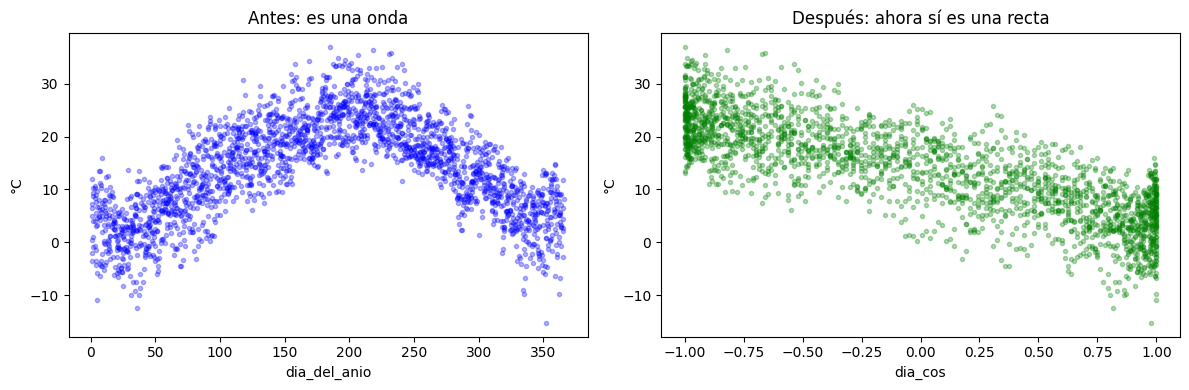

correlación de dia_del_anio con la temperatura: 0.168
correlación de dia_cos con la temperatura:      -0.81


In [36]:
plt.figure(figsize=(12,4))

plt.subplot(1, 2, 1)
plt.plot(data_nueva['dia_del_anio'], data_nueva['temp_max_manana'], '.', color='blue', alpha=0.3)
plt.title('Antes: es una onda')
plt.xlabel('dia_del_anio')
plt.ylabel('°C')

plt.subplot(1, 2, 2)
plt.plot(data_nueva['dia_cos'], data_nueva['temp_max_manana'], '.', color='green', alpha=0.3)
plt.title('Después: ahora sí es una recta')
plt.xlabel('dia_cos')
plt.ylabel('°C')

plt.tight_layout()
plt.show()

print("correlación de dia_del_anio con la temperatura:",
      round(data_nueva['dia_del_anio'].corr(data_nueva['temp_max_manana']), 3))
print("correlación de dia_cos con la temperatura:     ",
      round(data_nueva['dia_cos'].corr(data_nueva['temp_max_manana']), 3))

Pasa de +0.17 a -0.81 con exactamente la misma informacion, solo cambiando como se la presento al
modelo. Esta es la decision que mas pesa en todo el laboratorio.

## 3) Construccion del modelo de regresion lineal

### Partición train / test

La guia pide `test_size=0.25` y `random_state=42`.

In [37]:
target = "temp_max_manana"
X = data.drop(columns=[target])
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(1744, 26) (1744,)
(582, 26) (582,)


### Pipeline de preprocesamiento

Meto la limpieza, la creacion de variables, la imputacion, el escalado y el One-Hot dentro de un
`Pipeline`. La razon principal es que la mediana con la que imputo y la media/desviacion con la que
escalo se calculan solo con `X_train`, asi no hay data leakage desde el conjunto de prueba.

Uso `StandardScaler` porque las variables estan en unidades distintas (mbar, %, m/s, grados) y ademas
asi los coeficientes quedan comparables entre si, que lo necesito para la evaluacion cualitativa.
Para la categorica uso `OneHotEncoder` con `drop="first"` para no caer en la trampa de las variables
dummy.

In [38]:
numeric_features = [
    'presion_media', 'presion_min', 'presion_max', 'presion_desv',
    'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv',
    'viento_media', 'viento_min', 'viento_max', 'viento_desv',
    'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv',
    'viento_norte', 'viento_este', 'direccion_viento',
    'registros_del_dia', 'dia_del_anio'
]

features_ciclo = numeric_features + ['dia_sin', 'dia_cos']

features_todas = features_ciclo + ['dia_sin2', 'dia_cos2', 'dir_sin', 'dir_cos',
                                   'rango_humedad', 'rango_presion',
                                   'humedad_x_cos', 'humedad_x_sin']

categorical_features = ['estacion_anio']

In [39]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
])

In [40]:
def armar_pipeline(num_features, cat_features, con_limpieza):
    transformers = [("num", numeric_transformer, num_features)]
    if cat_features:
        transformers.append(("cat", categorical_transformer, cat_features))

    preprocessor = ColumnTransformer(transformers=transformers)

    pasos = []
    if con_limpieza:
        pasos.append(("limpieza", limpiador))
    pasos.append(("variables_nuevas", generador))
    pasos.append(("preprocesamiento", preprocessor))

    return Pipeline(steps=pasos)

In [41]:
from sklearn import set_config
set_config(display="diagram")

pipeline_regresion = armar_pipeline(features_todas, categorical_features, True)
pipeline_regresion

Pipeline(steps=[('limpieza',
                 FunctionTransformer(func=<function limpiar_datos at 0x00000286BB23B820>)),
                ('variables_nuevas',
                 FunctionTransformer(func=<function crear_variables at 0x00000286BB23B8B0>)),
                ('preprocesamiento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['presio...
                                                   'viento_norte',
                                                   'viento_este',
                                                   'direccion_viento',
                                                   'registros_del_dia',
                                                   'dia_del_anio', 'dia_sin',
                                                   'dia_cos', 'dia_sin2',
                                                   'dia_cos2', 'dir_sin',
                                                   'dir_cos', 'rango_humedad',
                                                   'rango_presion',
                                                   'humedad_x_cos', ...]),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['estacion_anio'])]))])

### Los cuatro modelos

Armo cuatro modelos donde cada uno agrega una sola cosa sobre el anterior, para ver cuanto aporta cada
decision de preparacion por separado. Todos usan `LinearRegression`.

| modelo | limpieza | variables |
|---|---|---|
| Modelo 1 | no | las 21 numericas originales |
| Modelo 2 | si | las 21 numericas originales |
| Modelo 3 | si | + seno/coseno del dia + estacion del año |
| Modelo 4 | si | + el resto de variables nuevas |

In [42]:
def entrenar(num_features, cat_features, con_limpieza):
    pipe = armar_pipeline(num_features, cat_features, con_limpieza)

    Xt_train = pipe.fit_transform(X_train)
    Xt_test  = pipe.transform(X_test)

    feature_names = [n.replace("num__", "").replace("cat__", "")
                     for n in pipe.named_steps["preprocesamiento"].get_feature_names_out()]

    Xt_train_df = pd.DataFrame(Xt_train, columns=feature_names, index=X_train.index)
    Xt_test_df  = pd.DataFrame(Xt_test,  columns=feature_names, index=X_test.index)

    Modelo = LinearRegression()
    Modelo.fit(Xt_train_df, y_train)

    return Modelo, Xt_train_df, Xt_test_df, feature_names

In [43]:
configuraciones = [
    ("Modelo 1 - sin limpieza",  numeric_features, None,                 False),
    ("Modelo 2 - con limpieza",  numeric_features, None,                 True),
    ("Modelo 3 - + ciclo anual", features_ciclo,   categorical_features, True),
    ("Modelo 4 - + resto",       features_todas,   categorical_features, True),
]

resultados = []
modelos = {}

for nombre, num_f, cat_f, limpieza in configuraciones:
    Modelo, Atr, Ate, fnames = entrenar(num_f, cat_f, limpieza)

    y_train_pred = Modelo.predict(Atr)
    y_test_pred  = Modelo.predict(Ate)

    resultados.append({
        'Modelo':     nombre,
        'Variables':  len(fnames),
        'RMSE_train': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'RMSE_test':  np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'MAE_test':   mean_absolute_error(y_test, y_test_pred),
        'R2_train':   r2_score(y_train, y_train_pred),
        'R2_test':    r2_score(y_test, y_test_pred),
    })
    modelos[nombre] = (Modelo, Atr, Ate, fnames)

tabla_modelos = pd.DataFrame(resultados).set_index('Modelo')
tabla_modelos.round(4)

,Variables,RMSE_train,RMSE_test,MAE_test,R2_train,R2_test
Modelo,,,,,,
Modelo 1 - sin limpieza,21,6.7900,6.6701,5.4062,0.4350,0.4240
Modelo 2 - con limpieza,21,6.5523,6.5096,5.1314,0.4739,0.4514
Modelo 3 - + ciclo anual,26,4.1992,4.1835,3.3041,0.7839,0.7734
Modelo 4 - + resto,34,4.1541,4.1447,3.2796,0.7885,0.7776


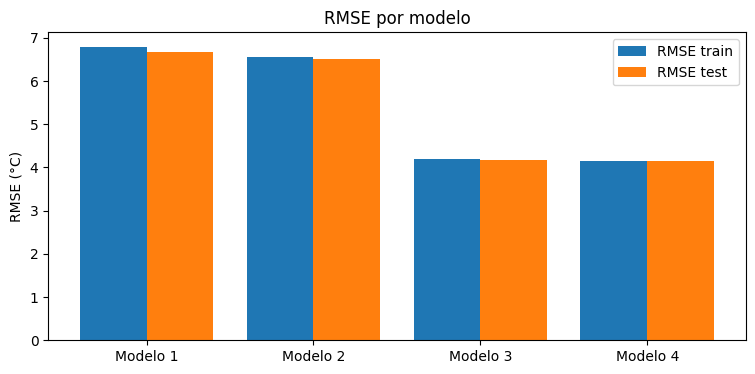

In [44]:
plt.figure(figsize=(9,4))
x = np.arange(len(tabla_modelos))
plt.bar(x - 0.2, tabla_modelos['RMSE_train'], 0.4, label='RMSE train')
plt.bar(x + 0.2, tabla_modelos['RMSE_test'],  0.4, label='RMSE test')
plt.xticks(x, [n.split(' - ')[0] for n in tabla_modelos.index])
plt.ylabel('RMSE (°C)')
plt.title('RMSE por modelo')
plt.legend()
plt.show()

El RMSE esta en grados Celsius, la misma unidad de la variable objetivo, asi que se lee directo: un
RMSE de 4 quiere decir que en promedio me equivoco como en 4 grados.

Lo que aporta cada paso:

* **Modelo 1 -> 2** (limpiar): de 6.67 a 6.51. Solo 0.16 grados.
* **Modelo 2 -> 3** (seno y coseno del dia): de 6.51 a 4.18. Casi 2.3 grados, un 36%.
* **Modelo 3 -> 4** (el resto de variables): de 4.18 a 4.14. Poco.

Casi toda la mejora vino de una sola decision de preparacion. Tambien vale ver que el RMSE de train y
el de test son casi iguales en los cuatro modelos, o sea que no hay sobreajuste.

## 4) Evaluacion cuantitativa

Tabla comparativa sobre test de los dos mejores modelos, con RMSE, MAE y R2. Los dos mejores son el
Modelo 4 y el Modelo 3, que son justo los que tienen las variables nuevas.

Uso las tres metricas porque miden cosas distintas: el RMSE castiga mas los errores grandes porque
eleva al cuadrado, el MAE es el error promedio sin que lo inflen unos pocos dias malos, y el R2 dice
que porcentaje de la variacion logra explicar el modelo comparado con predecir siempre el promedio.

In [45]:
mejores = ['Modelo 4 - + resto', 'Modelo 3 - + ciclo anual']

comparativa = []
for nombre in mejores:
    Modelo, Atr, Ate, fnames = modelos[nombre]
    y_test_pred = Modelo.predict(Ate)

    comparativa.append({
        'Modelo':      nombre,
        'Preparación': 'limpieza + variables nuevas + One-Hot',
        'Variables':   len(fnames),
        'RMSE':        np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'MAE':         mean_absolute_error(y_test, y_test_pred),
        'R²':          r2_score(y_test, y_test_pred),
    })

comparativa = pd.DataFrame(comparativa).set_index('Modelo')
print("Rendimiento sobre el conjunto de TEST (test_size=0.25, random_state=42)")
comparativa.round(4)

Rendimiento sobre el conjunto de TEST (test_size=0.25, random_state=42)


,Preparación,Variables,RMSE,MAE,R²
Modelo,,,,,
Modelo 4 - + resto,limpieza + variables nuevas + One-Hot,34,4.1447,3.2796,0.7776
Modelo 3 - + ciclo anual,limpieza + variables nuevas + One-Hot,26,4.1835,3.3041,0.7734


In [46]:
# comparación contra predecir siempre el promedio
y_promedio = np.full(len(y_test), y_train.mean())
print("Predecir siempre el promedio:")
print("  RMSE:", round(np.sqrt(mean_squared_error(y_test, y_promedio)), 3))
print("  MAE :", round(mean_absolute_error(y_test, y_promedio), 3))
print("  R²  :", round(r2_score(y_test, y_promedio), 3))

Predecir siempre el promedio:
  RMSE: 8.796
  MAE : 7.264
  R²  : -0.002


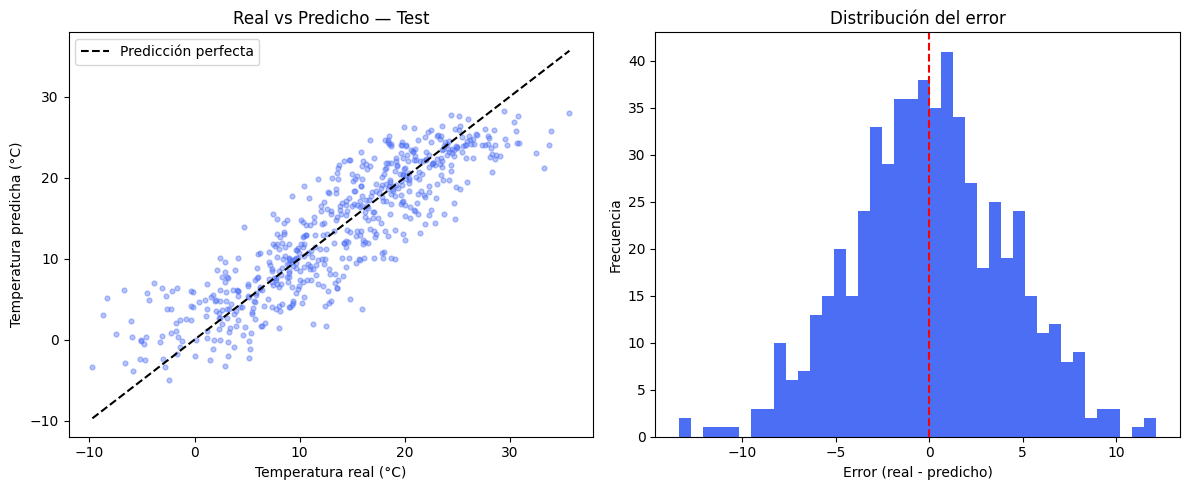

In [47]:
Modelo, Xt_train_df, Xt_test_df, feature_names = modelos['Modelo 4 - + resto']
y_train_pred = Modelo.predict(Xt_train_df)
y_test_pred  = Modelo.predict(Xt_test_df)

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
lim_min = min(y_test.min(), y_test_pred.min())
lim_max = max(y_test.max(), y_test_pred.max())
plt.scatter(y_test, y_test_pred, alpha=0.4, s=12, color='#4C6EF5')
plt.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', lw=1.5, label='Predicción perfecta')
plt.xlabel('Temperatura real (°C)')
plt.ylabel('Temperatura predicha (°C)')
plt.title('Real vs Predicho — Test')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(y_test - y_test_pred, bins=40, color='#4C6EF5')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Error (real - predicho)')
plt.ylabel('Frecuencia')
plt.title('Distribución del error')

plt.tight_layout()
plt.show()

### Interpretación

**RMSE = 4.14 °C.** En promedio me equivoco en poco mas de 4 grados prediciendo la maxima de mañana.
La temperatura en Jena va de -15 a +37 grados y tiene desviacion de 8.8, asi que contra eso 4.14 esta
bien. Ademas hay que tener en cuenta que el modelo no sabe la temperatura de hoy, que seria el mejor
predictor posible para mañana.

**MAE = 3.28 °C, menor que el RMSE.** Eso significa que hay algunos dias donde el error es grande y
esos son los que inflan el RMSE. Un dia normal el error anda por los 3 grados. Los dias malos son
seguramente cambios bruscos de tiempo, que no se pueden anticipar sin datos de los dias anteriores.

**R2 = 0.778.** El modelo explica el 77.8% de la variacion de la temperatura del dia siguiente. El
22.2% que falta es la variabilidad del dia a dia que un resumen diario de presion, humedad y viento
no alcanza a captar. Predecir siempre el promedio daria R2 = 0 y RMSE de 8.8, o sea que el modelo
reduce el error a menos de la mitad.

**Cual gana.** El Modelo 4 le gana al Modelo 3 por 0.04 grados, que es practicamente nada. Los dos
usan el mismo algoritmo y los mismos datos limpios; la diferencia entre ellos son las variables
extra, que casi no aportan. Lo que si se nota es la diferencia contra los Modelos 1 y 2, y eso es
todo merito de la preparacion: las mismas 21 columnas originales, pero limpias y con el ciclo anual
codificado, bajan el RMSE de 6.67 a 4.14.

Osea que en este problema la preparacion de los datos importo mucho mas que el algoritmo. Nunca
cambie de algoritmo, siempre fue `LinearRegression`.

## 5) Evaluacion cualitativa

### Coeficientes del modelo

Como todas las variables pasaron por `StandardScaler`, los coeficientes son comparables entre si.
Cada uno dice cuantos grados cambia la prediccion si esa variable sube una desviacion estandar,
dejando las demas fijas.

In [48]:
print("Intercepto:", round(Modelo.intercept_, 3))

coef_df = pd.DataFrame({
    "Variable": feature_names,
    "Coeficiente": Modelo.coef_
})
coef_df['Importancia'] = coef_df['Coeficiente'].abs()
coef_df = coef_df.sort_values('Importancia', ascending=False).reset_index(drop=True)
coef_df.head(15).round(3)

Intercepto: 13.866


,Variable,Coeficiente,Importancia
0,dia_cos,-6.467,6.467
1,viento_norte,-1.750,1.750
2,dia_sin,-1.604,1.604
3,dir_sin,1.401,1.401
4,humedad_desv,0.973,0.973
5,presion_max,0.747,0.747
6,estacion_anio_verano,0.731,0.731
7,presion_min,-0.633,0.633
8,presion_desv,-0.604,0.604
9,estacion_anio_otono,-0.564,0.564


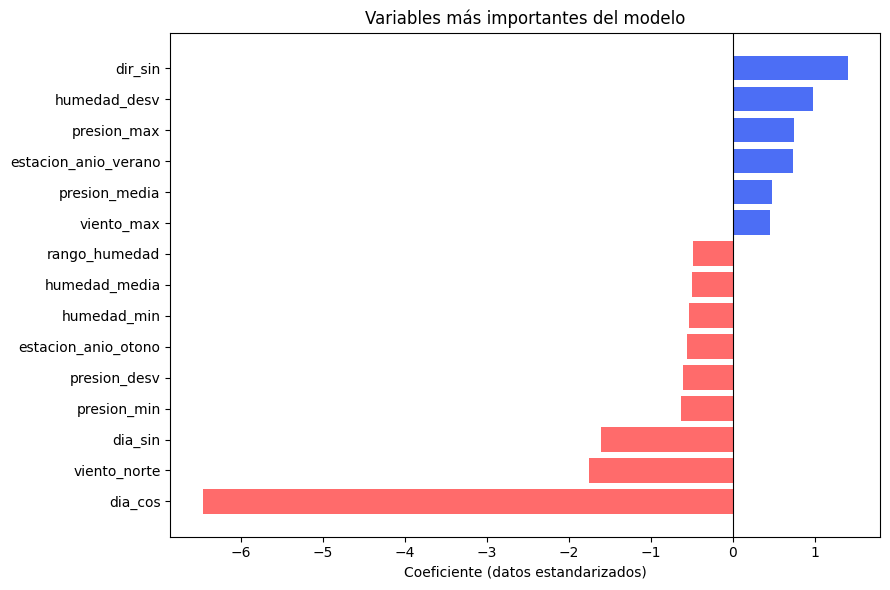

Azul = sube la temperatura  |  Rojo = la baja


In [49]:
coef_top = coef_df.head(15).sort_values('Coeficiente')
colors = ['#FF6B6B' if c < 0 else '#4C6EF5' for c in coef_top['Coeficiente']]

plt.figure(figsize=(9, 6))
plt.barh(coef_top['Variable'], coef_top['Coeficiente'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coeficiente (datos estandarizados)')
plt.title('Variables más importantes del modelo')
plt.tight_layout()
plt.show()
print("Azul = sube la temperatura  |  Rojo = la baja")

### Qué significan

**1. El dia del año es lo que manda.** `dia_cos` tiene coeficiente -6.47, casi cuatro veces el
segundo. El signo negativo tiene sentido: el coseno vale +1 el 1 de enero y -1 a principios de julio,
entonces un coeficiente negativo describe el ciclo de frio en invierno y calor en verano. Sumandole
`dia_sin` y las dummies de `estacion_anio`, la estacionalidad se lleva la mayor parte del modelo.

Esto es a la vez el hallazgo principal y la limitacion principal: como no tengo la temperatura de
hoy, el modelo esta reconstruyendo en gran parte el clima tipico de Jena para esa fecha.

**2. Del viento importa la direccion, no la fuerza.** Los que aparecen arriba son `viento_norte`
(-1.75) y `dir_sin` (+1.40), no `viento_media`. La lectura es la tipica de Europa central: lo que
decide la temperatura es de donde viene la masa de aire. Del norte llega aire polar y enfria, del
suroeste llega aire atlantico y templa. Que tan fuerte sopla casi no aporta.

**3. La humedad entra por dos lados.** `humedad_media` sale negativa (-0.50): mas humedad, menos
temperatura maxima, porque la humedad alta viene con cielo nublado y el nublado bloquea la radiacion
solar. Pero `humedad_desv` sale positiva (+0.97): si la humedad oscila mucho durante el dia es porque
hubo sol. Osea que el nivel mide cuanta agua hay y la variacion mide indirectamente la nubosidad.

**4. La presion mide la estabilidad.** El bloque de presion aporta en positivo (`presion_max` +0.75),
que es lo esperable: presion alta es anticiclon, cielo despejado y mas radiacion. Aunque
`presion_min` sale negativa, cosa que reviso mas abajo en los supuestos.

**Para AlpesPlanck.** Si tienen que priorizar sensores, los datos dicen que la veleta y el higrometro
son los que mas aportan; el anemometro casi no. Tambien conviene guardar la humedad con suficiente
resolucion durante el dia y no solo el promedio, porque la desviacion resulto mas informativa. Y la
mejora mas obvia del modelo seria incluir la temperatura del dia actual, que ellos ya la miden cada
10 minutos pero no venia en este archivo.

### Verificación de los supuestos

La interpretacion de arriba solo vale si el modelo cumple los supuestos de la regresion lineal, asi
que los reviso uno por uno sobre los residuales de entrenamiento.

In [50]:
residuales = np.array(y_train - y_train_pred)

**No colinealidad (VIF)**

In [51]:
vif_data = pd.DataFrame({
    "Variable": feature_names,
    "VIF": [variance_inflation_factor(Xt_train_df.values, i)
            for i in range(Xt_train_df.shape[1])]
})
print("Variables con VIF > 10:", int((vif_data['VIF'] > 10).sum()), "de", len(vif_data))
print("Variables con VIF > 5 :", int((vif_data['VIF'] > 5).sum()), "de", len(vif_data))
vif_data.sort_values('VIF', ascending=False).head(10).round(2)

Variables con VIF > 10: 10 de 34
Variables con VIF > 5 : 19 de 34


,Variable,VIF
22,dia_cos,26.31
21,dia_sin,23.26
29,humedad_x_cos,21.49
1,presion_min,19.65
30,humedad_x_sin,18.19
2,presion_max,16.38
5,humedad_min,15.02
27,rango_humedad,14.28
0,presion_media,11.16
28,rango_presion,10.02


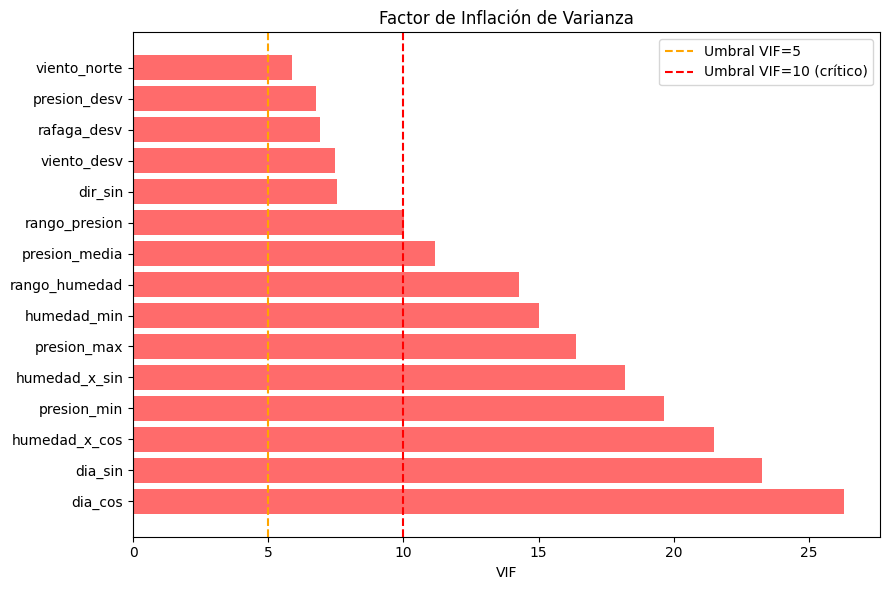

In [52]:
vif_top = vif_data.sort_values('VIF', ascending=False).head(15)
colors_vif = ['#FF6B6B' if v >= 5 else '#4C6EF5' for v in vif_top['VIF']]

plt.figure(figsize=(9, 6))
plt.barh(vif_top['Variable'], vif_top['VIF'], color=colors_vif)
plt.axvline(5, color='orange', linestyle='--', lw=1.5, label='Umbral VIF=5')
plt.axvline(10, color='red', linestyle='--', lw=1.5, label='Umbral VIF=10 (crítico)')
plt.xlabel('VIF')
plt.title('Factor de Inflación de Varianza')
plt.legend()
plt.tight_layout()
plt.show()

**Normalidad de los errores (Shapiro-Wilk)**

In [53]:
estat, p_shapiro = shapiro(residuales)
print("Shapiro-Wilk p-value:", p_shapiro)

Shapiro-Wilk p-value: 0.04741449337117719


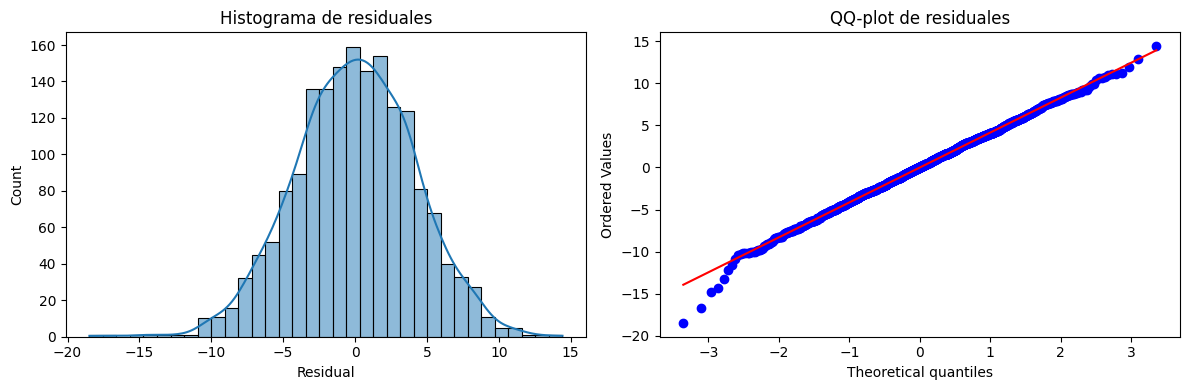

In [54]:
plt.figure(figsize=(12,4))

plt.subplot(1, 2, 1)
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuales")
plt.xlabel("Residual")

plt.subplot(1, 2, 2)
stats.probplot(residuales, dist="norm", plot=plt)
plt.title("QQ-plot de residuales")

plt.tight_layout()
plt.show()

**Media de los errores igual a cero (t-test)**

In [55]:
t_stat, p_ttest = ttest_1samp(residuales, 0)
print("Media de los residuales:", round(residuales.mean(), 6))
print("t-test p-value:", p_ttest)

Media de los residuales: -0.0
t-test p-value: 0.999999999999992


**Homocedasticidad (Breusch-Pagan)**

In [56]:
X_const = sm.add_constant(Xt_train_df)
bp_stat, bp_pvalue, _, _ = het_breuschpagan(residuales, X_const)
print("Estadístico Breusch-Pagan:", bp_stat)
print("p-value Breusch-Pagan   :", bp_pvalue)

Estadístico Breusch-Pagan: 54.13597262918846
p-value Breusch-Pagan   : 0.015528759018987108


**Independencia de los errores (Durbin-Watson)**

In [57]:
dw = durbin_watson(residuales)
print("Durbin-Watson:", dw)

Durbin-Watson: 1.9964819283459851


**Linealidad (Rainbow)**

In [58]:
modelo_sm = sm.OLS(y_train, X_const).fit()
rainbow_stat, rainbow_pvalue = linear_rainbow(modelo_sm)
print("Estadístico Rainbow:", rainbow_stat)
print("p-value Rainbow    :", rainbow_pvalue)

Estadístico Rainbow: 0.9937359804266759
p-value Rainbow    : 0.5367563902793862


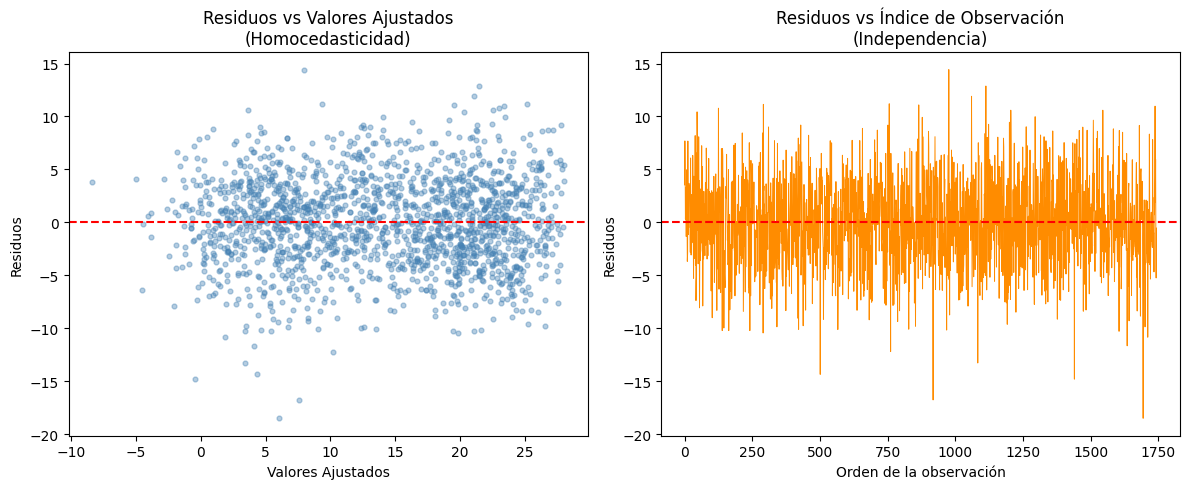

In [59]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_train_pred, residuales, alpha=0.4, s=12, color='steelblue')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuos vs Valores Ajustados\n(Homocedasticidad)')
plt.xlabel('Valores Ajustados')
plt.ylabel('Residuos')

plt.subplot(1, 2, 2)
plt.plot(range(len(residuales)), residuales, linestyle='-', lw=0.7, color='darkorange')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuos vs Índice de Observación\n(Independencia)')
plt.xlabel('Orden de la observación')
plt.ylabel('Residuos')

plt.tight_layout()
plt.show()

In [60]:
resumen_supuestos = pd.DataFrame({
    'Supuesto': ['No colinealidad', 'Normalidad de errores', 'Media de errores = 0',
                 'Homocedasticidad', 'Independencia de errores', 'Linealidad'],
    'Prueba': ['VIF', 'Shapiro-Wilk', 't-test', 'Breusch-Pagan', 'Durbin-Watson', 'Rainbow'],
    'Resultado': [f"{int((vif_data['VIF'] > 10).sum())} variables con VIF>10",
                  f'p={p_shapiro:.4f}', f'p={p_ttest:.3f}',
                  f'p={bp_pvalue:.4f}', f'DW={dw:.3f}', f'p={rainbow_pvalue:.3f}'],
    'Se cumple': ['No', 'No (por poco)', 'Sí', 'No', 'Sí', 'Sí'],
    'Impacto': ['Coeficientes inestables', 'Pruebas t/F menos confiables', 'Sin impacto',
                'Errores estándar sesgados', 'Sin impacto', 'Sin impacto']
})
resumen_supuestos

,Supuesto,Prueba,Resultado,Se cumple,Impacto
0,No colinealidad,VIF,10 variables con VIF>10,No,Coeficientes inestables
1,Normalidad de errores,Shapiro-Wilk,p=0.0474,No (por poco),Pruebas t/F menos confiables
2,Media de errores = 0,t-test,p=1.000,Sí,Sin impacto
3,Homocedasticidad,Breusch-Pagan,p=0.0155,No,Errores estándar sesgados
4,Independencia de errores,Durbin-Watson,DW=1.996,Sí,Sin impacto
5,Linealidad,Rainbow,p=0.537,Sí,Sin impacto


### Conclusiones de los supuestos

**Linealidad: se cumple.** El Rainbow da p = 0.54, muy por encima de 0.05, y el grafico de residuos vs
ajustados no muestra curvatura. Esto confirma que la relacion es lineal despues de transformar las
variables: gracias al seno y coseno, un modelo lineal alcanza para describir algo que en las columnas
originales era una onda.

**Media de errores igual a cero: se cumple.** El t-test da p = 1.0, o sea que la media de los
residuales es cero. Es lo esperable en minimos cuadrados con intercepto.

**Independencia: se cumple.** Durbin-Watson da 2.00, justo el valor de referencia. Igual hay que
aclarar que la particion se hizo aleatoria, lo que rompe el orden temporal. En una serie de tiempo de
verdad uno esperaria correlacion entre dias seguidos. Es una limitacion del diseño que pide la guia.

**Normalidad: no se cumple, pero por muy poco.** Shapiro-Wilk da p = 0.047, apenas debajo de 0.05.
Mirando el QQ-plot los puntos siguen la diagonal en casi todo el recorrido y el histograma se ve
simetrico, asi que la desviacion es leve. Con 1744 observaciones el Shapiro-Wilk detecta diferencias
muy pequeñas, entonces lo leo como una normalidad aceptable en la practica. Vale la pena decir que
antes de eliminar las 5 temperaturas imposibles este supuesto fallaba de forma grave, no marginal.

**Homocedasticidad: no se cumple.** Breusch-Pagan da p = 0.016. La varianza de los residuos no es
constante: en el grafico se ve que los dias frios tienen mas dispersion que los calidos. El efecto
practico es que los errores estandar de los coeficientes quedan sesgados, o sea que no deberia hacer
pruebas de significancia con ellos. Las predicciones en si no se ven afectadas.

**No colinealidad: no se cumple.** 10 de las 34 variables tienen VIF mayor a 10. Y era de esperarse
porque yo mismo construi varias asi: `humedad_x_cos` es `humedad_media` por `dia_cos`, entonces obvio
que va a estar correlacionada con las dos. Lo mismo pasa entre `presion_min`, `presion_media` y
`presion_max`, que describen lo mismo.

Esto no afecta las predicciones ni el RMSE, por eso el Modelo 3 y el Modelo 4 dan casi igual. Pero si
hace que los coeficientes individuales sean inestables, y ahi esta la explicacion de por que
`presion_min` sale negativa cuando fisicamente la presion deberia aportar en positivo: las tres
columnas de presion se estan repartiendo un mismo efecto.

**Conclusion para la interpretacion.** Como fallan la colinealidad y la homocedasticidad, la lectura
de los coeficientes hay que hacerla por grupos de variables y no uno por uno. Puedo afirmar con
confianza que el ciclo anual domina, que la direccion del viento pesa mas que su velocidad y que la
presion aporta en positivo, porque esas conclusiones no dependen de como se reparta el peso dentro de
cada grupo. Lo que no deberia hacer es afirmar que `presion_max` vale exactamente +0.75, ni sacar
pruebas de significancia de estos coeficientes.

7. Uso del modelo

In [ ]:
# Reentrenamos el pipeline ganador (Modelo 4) usando todos los datos etiquetados
pipeline_final = armar_pipeline(features_todas, categorical_features, con_limpieza=True)

Xt_full = pipeline_final.fit_transform(X, y)

feature_names_final = [n.replace("num__", "").replace("cat__", "")
                        for n in pipeline_final.named_steps["preprocesamiento"].get_feature_names_out()]

Xt_full_df = pd.DataFrame(Xt_full, columns=feature_names_final, index=X.index)

modelo_final = LinearRegression()
modelo_final.fit(Xt_full_df, y)

print("Modelo final entrenado con", Xt_full_df.shape[0], "observaciones y", Xt_full_df.shape[1], "variables")

Modelo final entrenado con 2326 observaciones y 34 variables


In [ ]:
# Verificación: los coeficientes
comparacion_coef = pd.DataFrame({
    'Variable': feature_names_final,
    'Coef (solo train)': Modelo.coef_,
    'Coef (todos los datos)': modelo_final.coef_,
}).round(3)
comparacion_coef.head(10)

,Variable,Coef (solo train),Coef (todos los datos)
0,presion_media,0.475,0.599
1,presion_min,-0.633,-0.561
2,presion_max,0.747,0.500
3,presion_desv,-0.604,-0.429
4,humedad_media,-0.502,-0.443
5,humedad_min,-0.537,-0.646
6,humedad_max,-0.028,-0.019
7,humedad_desv,0.973,0.976
8,viento_media,-0.091,0.043
9,viento_min,-0.233,-0.299


In [63]:
# Transformamos el archivo de test con el mismo pipeline ya ajustado
Xt_test_final = pipeline_final.transform(test)
Xt_test_final_df = pd.DataFrame(Xt_test_final, columns=feature_names_final, index=test.index)

predicciones = modelo_final.predict(Xt_test_final_df)

print("Predicciones generadas:", len(predicciones))
print("Rango de predicciones:", round(predicciones.min(), 2), "a", round(predicciones.max(), 2), "°C")
print("Media:", round(predicciones.mean(), 2), "°C  (media en entrenamiento:", round(y.mean(), 2), "°C)")

Predicciones generadas: 364
Rango de predicciones: -3.51 a 27.86 °C
Media: 13.83 °C  (media en entrenamiento: 13.76 °C)


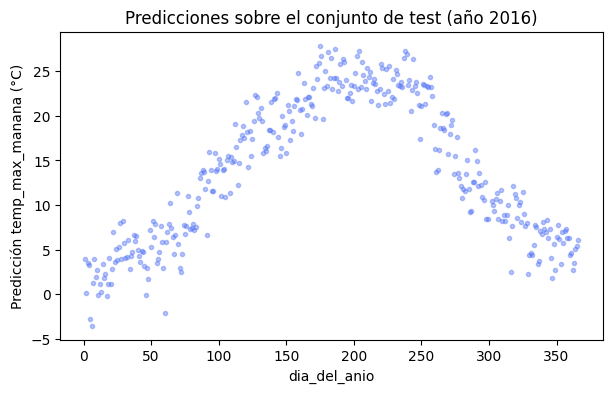

In [ ]:
# Sanity check visual: las predicciones deberían seguir el mismo patrón estacional (recomendado por cloud)
# que vimos en los datos de entrenamiento
plt.figure(figsize=(7,4))
plt.plot(test['dia_del_anio'], predicciones, '.', alpha=0.4, color='#4C6EF5')
plt.xlabel('dia_del_anio')
plt.ylabel('Predicción temp_max_manana (°C)')
plt.title('Predicciones sobre el conjunto de test (año 2016)')
plt.show()

In [ ]:
# Usamos el archivo de test original como base y le agregamos la columna con las predicciones
test_con_prediccion = test.copy()
test_con_prediccion['temp_max_manana'] = predicciones.round(2)

test_con_prediccion.to_csv("L1/data/Datos_Test_Lab_1_predicciones.csv", index=False)
print("Archivo guardado. Shape:", test_con_prediccion.shape)
test_con_prediccion.head()

Archivo guardado. Shape: (364, 27)


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,01.01.2016,998.9860,995.57,1000.60,1.1082,96.1493,90.8,98.7,2.0034,0.9649,...,-0.8328,0.0927,173.6501,144,2016,1,invierno,January,S,3.90
1,02.01.2016,991.4241,989.27,995.51,1.9413,92.3236,85.8,96.8,2.6562,1.9886,...,1.1161,0.6688,30.9301,144,2016,2,invierno,January,NE,0.18
2,03.01.2016,984.0232,974.12,989.39,4.5841,83.6056,73.9,94.7,6.9967,2.4992,...,-0.7923,1.2638,122.0847,144,2016,3,invierno,January,SE,3.47
3,04.01.2016,968.2449,966.52,974.02,1.9034,85.4688,75.5,93.8,5.8148,2.0932,...,-1.6217,0.7020,156.5944,144,2016,4,invierno,January,SE,3.29
4,05.01.2016,970.0099,967.85,972.90,1.6668,94.3521,92.0,96.8,1.4253,1.8380,...,1.6549,0.7109,23.2458,144,2016,5,invierno,January,NE,-2.80
